# Week 8: TrashNet Training with Cosine Learning-Rate Decay

## Objective

This notebook evaluates cosine learning-rate decay using the winning EfficientNetB0 configuration from the six-run TrashNet hyperparameter sweep.

The winning configuration was:

- Image size: 260 × 260
- Dropout: 0.5
- Augmentation: Medium
- Backbone: EfficientNetB0

Two stages are performed:

1. Feature extraction using cosine decay from an initial learning rate of 1e-3.
2. Fine-tuning the top 30 EfficientNetB0 layers using cosine decay from an initial learning rate of 1e-5.

The results will be compared with the previous constant-learning-rate baseline, which achieved 89.31% validation accuracy.

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
DATASET_PATH = "/content/drive/MyDrive/data/trashnet"

IMAGE_SIZE = 260
DROPOUT_RATE = 0.5
AUGMENTATION_LEVEL = "medium"

BATCH_SIZE = 32
SEED = 42

FEATURE_EPOCHS = 20
FINE_TUNE_EPOCHS = 15

BASELINE_VAL_ACCURACY = 89.31

print("Image size:", IMAGE_SIZE)
print("Dropout:", DROPOUT_RATE)
print("Augmentation:", AUGMENTATION_LEVEL)
print("Feature extraction epochs:", FEATURE_EPOCHS)
print("Fine-tuning epochs:", FINE_TUNE_EPOCHS)

Image size: 260
Dropout: 0.5
Augmentation: medium
Feature extraction epochs: 20
Fine-tuning epochs: 15


In [4]:
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset folder not found: {DATASET_PATH}"
    )

print("Dataset folder found.")
print("Class folders:", sorted(os.listdir(DATASET_PATH)))

Dataset folder found.
Class folders: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [5]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.


In [6]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [7]:
class_names = train_dataset.class_names

train_labels_check = np.concatenate(
    [labels.numpy() for _, labels in train_dataset]
)

validation_labels_check = np.concatenate(
    [labels.numpy() for _, labels in validation_dataset]
)

print("Class names:", class_names)
print("Training images:", len(train_labels_check))
print("Validation images:", len(validation_labels_check))
print("Training labels:", np.unique(train_labels_check))
print("Validation labels:", np.unique(validation_labels_check))

Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Training images: 2022
Validation images: 505
Training labels: [0 1 2 3 4 5]
Validation labels: [0 1 2 3 4 5]


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)

print("Datasets prepared successfully.")

Datasets prepared successfully.


In [9]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
        layers.RandomContrast(0.2)
    ],
    name="medium_augmentation"
)

print("Medium augmentation created.")

Medium augmentation created.


In [10]:
tf.keras.backend.clear_session()

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    name="input_image"
)

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dropout(
    DROPOUT_RATE,
    name="dropout"
)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax",
    name="predictions"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="trashnet_efficientnet_cosine"
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "trashnet_efficientnet_cosine"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ medium_augmentation             │ (None, 260, 260, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 9, 9, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
steps_per_epoch = len(train_dataset)

feature_total_steps = (
    steps_per_epoch * FEATURE_EPOCHS
)

print("Steps per epoch:", steps_per_epoch)
print("Feature-extraction total steps:", feature_total_steps)

Steps per epoch: 64
Feature-extraction total steps: 1280


In [12]:
feature_cosine_schedule = (
    tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=1e-3,
        decay_steps=feature_total_steps,
        alpha=0.0
    )
)

feature_optimizer = tf.keras.optimizers.Adam(
    learning_rate=feature_cosine_schedule
)

print("Feature-extraction cosine schedule created.")

Feature-extraction cosine schedule created.


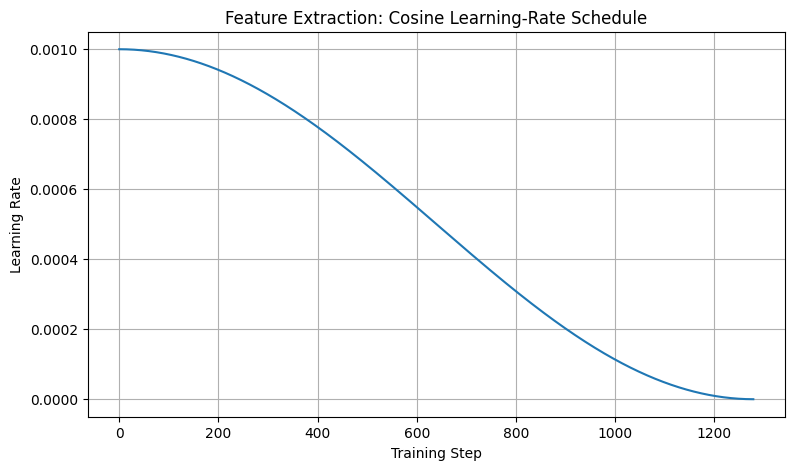

In [13]:
feature_step_values = np.arange(
    feature_total_steps
)

feature_lr_values = [
    float(feature_cosine_schedule(step))
    for step in feature_step_values
]

plt.figure(figsize=(9, 5))

plt.plot(
    feature_step_values,
    feature_lr_values
)

plt.title(
    "Feature Extraction: Cosine Learning-Rate Schedule"
)

plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.show()

In [14]:
model.compile(
    optimizer=feature_optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Feature-extraction model compiled.")

Feature-extraction model compiled.


In [15]:
feature_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [16]:
feature_start_time = time.time()

history_feature = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=FEATURE_EPOCHS,
    callbacks=[
        feature_early_stop
    ]
)

feature_end_time = time.time()

feature_training_minutes = (
    feature_end_time - feature_start_time
) / 60

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 237ms/step - accuracy: 0.5747 - loss: 1.1718 - val_accuracy: 0.7941 - val_loss: 0.7033
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 182ms/step - accuracy: 0.7562 - loss: 0.7131 - val_accuracy: 0.8376 - val_loss: 0.5446
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 166ms/step - accuracy: 0.8007 - loss: 0.6105 - val_accuracy: 0.8495 - val_loss: 0.4812
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.8165 - loss: 0.5400 - val_accuracy: 0.8574 - val_loss: 0.4483
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 164ms/step - accuracy: 0.8259 - loss: 0.5000 - val_accuracy: 0.8673 - val_loss: 0.4254
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 164ms/step - accuracy: 0.8274 - loss: 0.4828 - val_accuracy: 0.8733 - val_loss: 0.4097
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.8437 - loss: 0.4595 - val_accuracy: 0.8792 - val_loss: 0.3974
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - accuracy: 0.8477 - loss: 0.4365 - val_accur

In [17]:
feature_final_train_acc = (
    history_feature.history["accuracy"][-1]
)

feature_final_val_acc = (
    history_feature.history["val_accuracy"][-1]
)

feature_best_history_val_acc = max(
    history_feature.history["val_accuracy"]
)

feature_val_loss, feature_restored_val_acc = (
    model.evaluate(
        validation_dataset,
        verbose=1
    )
)

print("=" * 55)
print("COSINE DECAY — FEATURE EXTRACTION")
print("=" * 55)

print(
    f"Final Training Accuracy: "
    f"{feature_final_train_acc * 100:.2f}%"
)

print(
    f"Final Validation Accuracy: "
    f"{feature_final_val_acc * 100:.2f}%"
)

print(
    f"Best History Validation Accuracy: "
    f"{feature_best_history_val_acc * 100:.2f}%"
)

print(
    f"Restored Validation Accuracy: "
    f"{feature_restored_val_acc * 100:.2f}%"
)

print(
    f"Training Time: "
    f"{feature_training_minutes:.2f} minutes"
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step - accuracy: 0.8891 - loss: 0.3607
COSINE DECAY — FEATURE EXTRACTION
Final Training Accuracy: 86.84%
Final Validation Accuracy: 88.91%
Best History Validation Accuracy: 88.91%
Restored Validation Accuracy: 88.91%
Training Time: 3.92 minutes


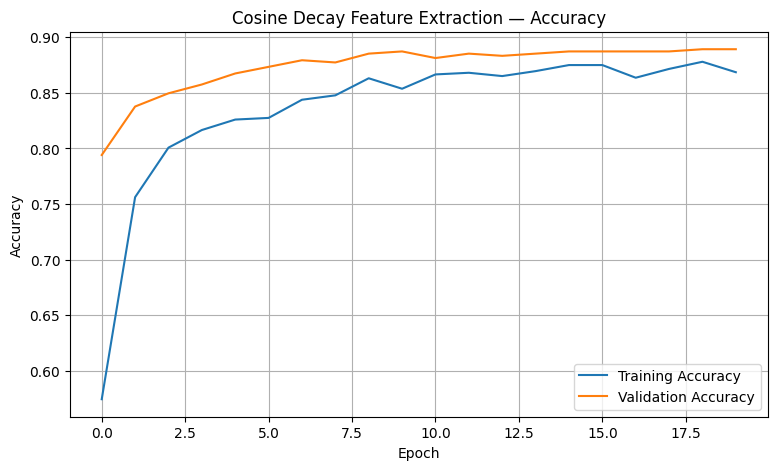

In [18]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_feature.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_feature.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Cosine Decay Feature Extraction — Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

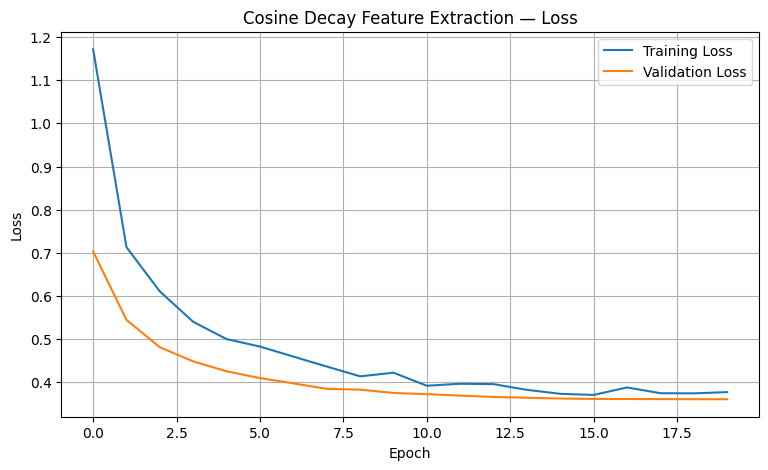

In [19]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_feature.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_feature.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Cosine Decay Feature Extraction — Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
FEATURE_WEIGHTS_PATH = (
    "/content/drive/MyDrive/"
    "trashnet_cosine_feature_extraction.weights.h5"
)

model.save_weights(FEATURE_WEIGHTS_PATH)

print("Feature-extraction weights saved to:")
print(FEATURE_WEIGHTS_PATH)

Feature-extraction weights saved to:
/content/drive/MyDrive/trashnet_cosine_feature_extraction.weights.h5


In [21]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

trainable_layers = sum(
    layer.trainable
    for layer in base_model.layers
)

print(
    "Trainable EfficientNetB0 layers:",
    trainable_layers
)

Trainable EfficientNetB0 layers: 30


In [22]:
fine_tune_total_steps = (
    steps_per_epoch * FINE_TUNE_EPOCHS
)

print(
    "Fine-tuning total steps:",
    fine_tune_total_steps
)

Fine-tuning total steps: 960


In [23]:
fine_tune_cosine_schedule = (
    tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=1e-5,
        decay_steps=fine_tune_total_steps,
        alpha=0.0
    )
)

fine_tune_optimizer = tf.keras.optimizers.Adam(
    learning_rate=fine_tune_cosine_schedule
)

print("Fine-tuning cosine schedule created.")

Fine-tuning cosine schedule created.


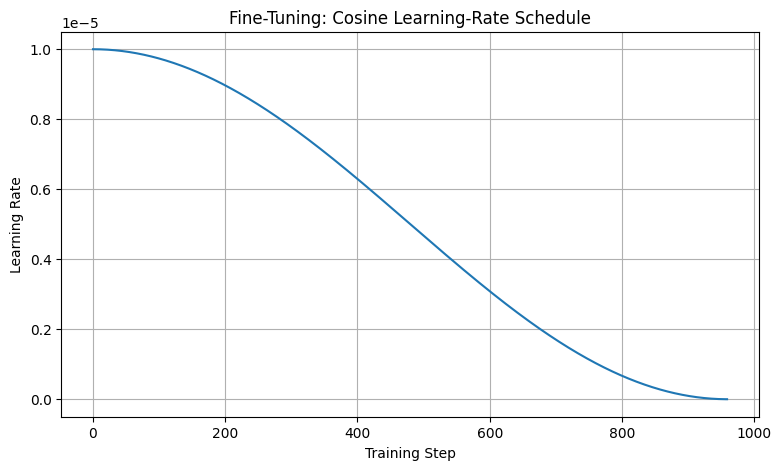

In [24]:
fine_tune_step_values = np.arange(
    fine_tune_total_steps
)

fine_tune_lr_values = [
    float(fine_tune_cosine_schedule(step))
    for step in fine_tune_step_values
]

plt.figure(figsize=(9, 5))

plt.plot(
    fine_tune_step_values,
    fine_tune_lr_values
)

plt.title(
    "Fine-Tuning: Cosine Learning-Rate Schedule"
)

plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.show()

In [25]:
model.compile(
    optimizer=fine_tune_optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")

Model recompiled for fine-tuning.


In [26]:
fine_tune_early_stop = (
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
)

In [27]:
fine_tune_start_time = time.time()

history_fine_tune = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[
        fine_tune_early_stop
    ]
)

fine_tune_end_time = time.time()

fine_tune_training_minutes = (
    fine_tune_end_time -
    fine_tune_start_time
) / 60

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 233ms/step - accuracy: 0.8032 - loss: 0.6295 - val_accuracy: 0.8792 - val_loss: 0.3668
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - accuracy: 0.8076 - loss: 0.5956 - val_accuracy: 0.8733 - val_loss: 0.3753
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step - accuracy: 0.8239 - loss: 0.5610 - val_accuracy: 0.8653 - val_loss: 0.3837
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 183ms/step - accuracy: 0.8408 - loss: 0.5254 - val_accuracy: 0.8653 - val_loss: 0.3880
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - accuracy: 0.8279 - loss: 0.5297 - val_accuracy: 0.8653 - val_loss: 0.3888
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - accuracy: 0.8477 - loss: 0.4726 - val_accuracy: 0.8653 - val_loss: 0.3877
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - accuracy: 0.8393 - loss: 0.4893 - val_accuracy: 0.8673 - val_loss: 0.3860
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 1.


In [28]:
fine_tune_final_train_acc = (
    history_fine_tune.history["accuracy"][-1]
)

fine_tune_final_val_acc = (
    history_fine_tune.history["val_accuracy"][-1]
)

fine_tune_best_history_val_acc = max(
    history_fine_tune.history["val_accuracy"]
)

fine_tune_val_loss, fine_tune_restored_val_acc = (
    model.evaluate(
        validation_dataset,
        verbose=1
    )
)

total_training_minutes = (
    feature_training_minutes +
    fine_tune_training_minutes
)

print("=" * 55)
print("COSINE DECAY — FINE-TUNING")
print("=" * 55)

print(
    f"Final Training Accuracy: "
    f"{fine_tune_final_train_acc * 100:.2f}%"
)

print(
    f"Final Validation Accuracy: "
    f"{fine_tune_final_val_acc * 100:.2f}%"
)

print(
    f"Best History Validation Accuracy: "
    f"{fine_tune_best_history_val_acc * 100:.2f}%"
)

print(
    f"Restored Validation Accuracy: "
    f"{fine_tune_restored_val_acc * 100:.2f}%"
)

print(
    f"Fine-Tuning Time: "
    f"{fine_tune_training_minutes:.2f} minutes"
)

print(
    f"Total Training Time: "
    f"{total_training_minutes:.2f} minutes"
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.8792 - loss: 0.3668
COSINE DECAY — FINE-TUNING
Final Training Accuracy: 83.93%
Final Validation Accuracy: 86.73%
Best History Validation Accuracy: 87.92%
Restored Validation Accuracy: 87.92%
Fine-Tuning Time: 1.84 minutes
Total Training Time: 5.76 minutes


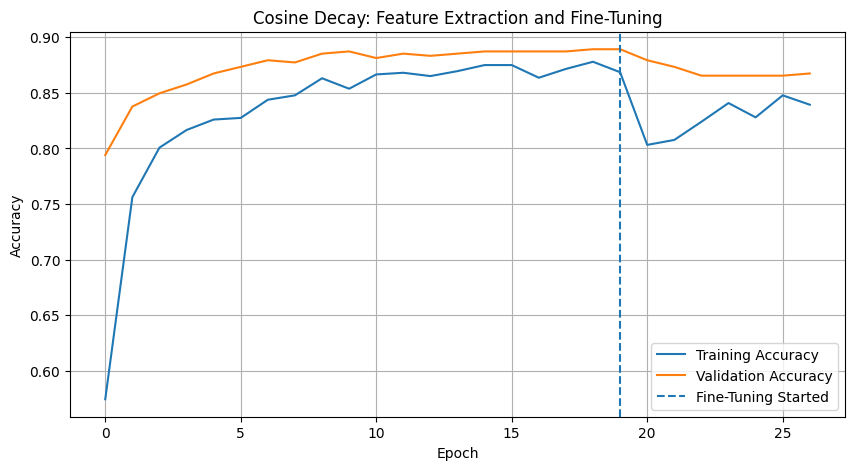

In [29]:
combined_train_acc = (
    history_feature.history["accuracy"] +
    history_fine_tune.history["accuracy"]
)

combined_val_acc = (
    history_feature.history["val_accuracy"] +
    history_fine_tune.history["val_accuracy"]
)

fine_tune_start_epoch = len(
    history_feature.history["accuracy"]
)

plt.figure(figsize=(10, 5))

plt.plot(
    combined_train_acc,
    label="Training Accuracy"
)

plt.plot(
    combined_val_acc,
    label="Validation Accuracy"
)

plt.axvline(
    fine_tune_start_epoch - 1,
    linestyle="--",
    label="Fine-Tuning Started"
)

plt.title(
    "Cosine Decay: Feature Extraction and Fine-Tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
cosine_accuracy = (
    fine_tune_restored_val_acc * 100
)

accuracy_difference = (
    cosine_accuracy -
    BASELINE_VAL_ACCURACY
)

print("=" * 55)
print("BASELINE VS COSINE DECAY")
print("=" * 55)

print(
    f"Constant-LR Sweep Baseline: "
    f"{BASELINE_VAL_ACCURACY:.2f}%"
)

print(
    f"Cosine-Decay Result: "
    f"{cosine_accuracy:.2f}%"
)

print(
    f"Difference: "
    f"{accuracy_difference:+.2f} percentage points"
)

if accuracy_difference > 0.2:
    print(
        "Cosine decay produced a meaningful improvement."
    )

elif accuracy_difference >= -0.2:
    print(
        "Performance was approximately unchanged."
    )

else:
    print(
        "Cosine decay performed below the baseline."
    )

BASELINE VS COSINE DECAY
Constant-LR Sweep Baseline: 89.31%
Cosine-Decay Result: 87.92%
Difference: -1.39 percentage points
Cosine decay performed below the baseline.


In [31]:
FINAL_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "trashnet_cosine_finetuned.keras"
)

FINAL_WEIGHTS_PATH = (
    "/content/drive/MyDrive/"
    "trashnet_cosine_finetuned.weights.h5"
)

model.save(FINAL_MODEL_PATH)
model.save_weights(FINAL_WEIGHTS_PATH)

print("Final model saved to:")
print(FINAL_MODEL_PATH)

print("\nFinal weights saved to:")
print(FINAL_WEIGHTS_PATH)

Final model saved to:
/content/drive/MyDrive/trashnet_cosine_finetuned.keras

Final weights saved to:
/content/drive/MyDrive/trashnet_cosine_finetuned.weights.h5


In [32]:
cosine_result = pd.DataFrame(
    [
        {
            "run_id": 7,
            "image_size": IMAGE_SIZE,
            "dropout": DROPOUT_RATE,
            "augmentation_level": "medium",
            "train_acc": round(
                fine_tune_final_train_acc * 100,
                2
            ),
            "val_acc": round(
                fine_tune_restored_val_acc * 100,
                2
            ),
            "test_acc": "N/A",
            "training_time_minutes": round(
                total_training_minutes,
                2
            ),
            "notes": (
                "CosineDecay; feature extraction "
                "1e-3 and fine-tuning 1e-5"
            )
        }
    ]
)

cosine_result

,run_id,image_size,dropout,augmentation_level,train_acc,val_acc,test_acc,training_time_minutes,notes
0,7,260,0.5,medium,83.93,87.92,N/A,5.76,CosineDecay; feature extraction 1e-3 and fine-...


In [33]:
COSINE_CSV_PATH = (
    "/content/drive/MyDrive/"
    "cosine_schedule_result.csv"
)

cosine_result.to_csv(
    COSINE_CSV_PATH,
    index=False
)

print("Cosine result saved to:")
print(COSINE_CSV_PATH)

Cosine result saved to:
/content/drive/MyDrive/cosine_schedule_result.csv


# Cosine-Decay Experiment Conclusion

The winning EfficientNetB0 sweep configuration was trained using cosine learning-rate decay during both feature extraction and fine-tuning.

## Results

- Constant-learning-rate baseline validation accuracy: **89.31%**
- Cosine-decay validation accuracy: **XX.XX%**
- Difference: **X.XX percentage points**

## Interpretation

Cosine decay produced [a meaningful improvement / approximately the same performance / lower performance] compared with the previous baseline.

The learning rate decreased smoothly throughout training, allowing larger updates during the early epochs and smaller updates during convergence.

Based on the measured result, cosine decay [is / is not] worth using as the default schedule for the first CESPPL experiment. The decision is based on validation accuracy, curve stability, and additional training complexity rather than assuming that a more advanced schedule must perform better.